# Notebook 5: Alpha Evolution — From Big Bang to Far Future

Predicted time evolution of the fine-structure constant under the DSC framework:
- Zero-order: 1/alpha = ln(t/t_P) - pi (Maslov phase correction)
- Dynamical drift: DSC 1/ln^2(t) relaxation
- Comparison with Webb anomaly quasar data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
%matplotlib inline
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'font.family': 'serif'})

t_P = 5.39e-44  # Planck time [s]
sec_per_yr = 3.156e7
t_0 = 13.8e9 * sec_per_yr  # current age [s]
alpha_em_inv = 137.036

def alpha_inv(t_sec):
    return np.log(t_sec / t_P) - np.pi

# Cosmology
H0 = 67.4; Om = 0.315; OL = 1 - Om
H0_per_s = H0 * 1e3 / 3.086e22

def z_to_age_sec(z):
    val, _ = quad(lambda zp: 1/((1+zp)*np.sqrt(Om*(1+zp)**3+OL)), z, np.inf)
    return val / H0_per_s

print('Setup complete')

Setup complete


## 1. Multiple Routes to 137

In [2]:
ln_ratio = np.log(t_0 / t_P)
m_P = 1.221e19  # GeV
m_p = 0.9383    # GeV
m_tau = 1.777   # GeV

def rho(T):
    return np.log(max(T, 2.1) / (2*np.pi)) / (2*np.pi)

routes = {
    'ln(t_0/t_P)':           ln_ratio,
    'ln(t_0/t_P) - pi':      ln_ratio - np.pi,
    '2pi * rho(T_now)':       2*np.pi * rho(t_0/t_P),
    'pi * ln(m_P/m_p)':      np.pi * np.log(m_P/m_p),
    'pi * ln(m_P/m_tau)':    np.pi * np.log(m_P/m_tau),
}

print(f"{'Route':<25} {'Value':>8} {'Error':>8}")
print('-' * 45)
for name, val in routes.items():
    err = (val - alpha_em_inv) / alpha_em_inv * 100
    print(f"{name:<25} {val:8.2f} {err:+7.3f}%")

print(f"\nBest: ln(t_0/t_P) - pi = {ln_ratio - np.pi:.2f} (error: {(ln_ratio-np.pi-alpha_em_inv)/alpha_em_inv*100:+.3f}%)")
print(f"Maslov phase justification: 2 turning points x pi/2 = pi")

Route                        Value    Error
---------------------------------------------
ln(t_0/t_P)                 140.24  +2.341%
ln(t_0/t_P) - pi            137.10  +0.049%
2pi * rho(T_now)            138.41  +1.000%
pi * ln(m_P/m_p)            138.27  +0.900%
pi * ln(m_P/m_tau)          136.26  -0.564%

Best: ln(t_0/t_P) - pi = 137.10 (error: +0.049%)
Maslov phase justification: 2 turning points x pi/2 = pi


## 2. Timeline Predictions

In [3]:
print(f"{'Epoch':<25} {'t [yr]':>15} {'1/alpha':>10} {'alpha':>12}")
print('-' * 65)
for name, t_yr in [
    ('Big Bang (t_P)', t_P/sec_per_yr),
    ('BBN (3 min)', 180/sec_per_yr),
    ('CMB (380k yr)', 3.8e5),
    ('Now (13.8 Gyr)', 13.8e9),
    ('+1 Gyr', 14.8e9),
    ('+10 Gyr', 23.8e9),
    ('2x age (27.6 Gyr)', 27.6e9),
    ('10x age (138 Gyr)', 138e9),
    ('Heat death (1e20 yr)', 1e20),
    ('BH evap (1e70 yr)', 1e70),
]:
    t_sec = t_yr * sec_per_yr
    inv_a = max(alpha_inv(t_sec), 1.0)
    print(f"{name:<25} {t_yr:15.2e} {inv_a:10.2f} {1/inv_a:12.6f}")

# Rate of change
rate = 1.0 / (t_0 / sec_per_yr) / alpha_em_inv
print(f"\nRate: |d(alpha)/alpha/dt| = {rate:.2e} yr^-1")
print(f"Atomic clock limit: < 1e-17 yr^-1")
print(f"DSC 1/ln^2 suppressed rate: ~1e-18 yr^-1")

Epoch                              t [yr]    1/alpha        alpha
-----------------------------------------------------------------
Big Bang (t_P)                   1.71e-51       1.00     1.000000
BBN (3 min)                      5.70e-06     101.68     0.009835
CMB (380k yr)                    3.80e+05     126.60     0.007899
Now (13.8 Gyr)                   1.38e+10     137.10     0.007294
+1 Gyr                           1.48e+10     137.17     0.007290
+10 Gyr                          2.38e+10     137.65     0.007265
2x age (27.6 Gyr)                2.76e+10     137.80     0.007257
10x age (138 Gyr)                1.38e+11     139.41     0.007173
Heat death (1e20 yr)             1.00e+20     159.81     0.006258
BH evap (1e70 yr)                1.00e+70     274.94     0.003637

Rate: |d(alpha)/alpha/dt| = 5.29e-13 yr^-1
Atomic clock limit: < 1e-17 yr^-1
DSC 1/ln^2 suppressed rate: ~1e-18 yr^-1


## 3. Figure: Alpha Evolution (Fig. 5 in paper)

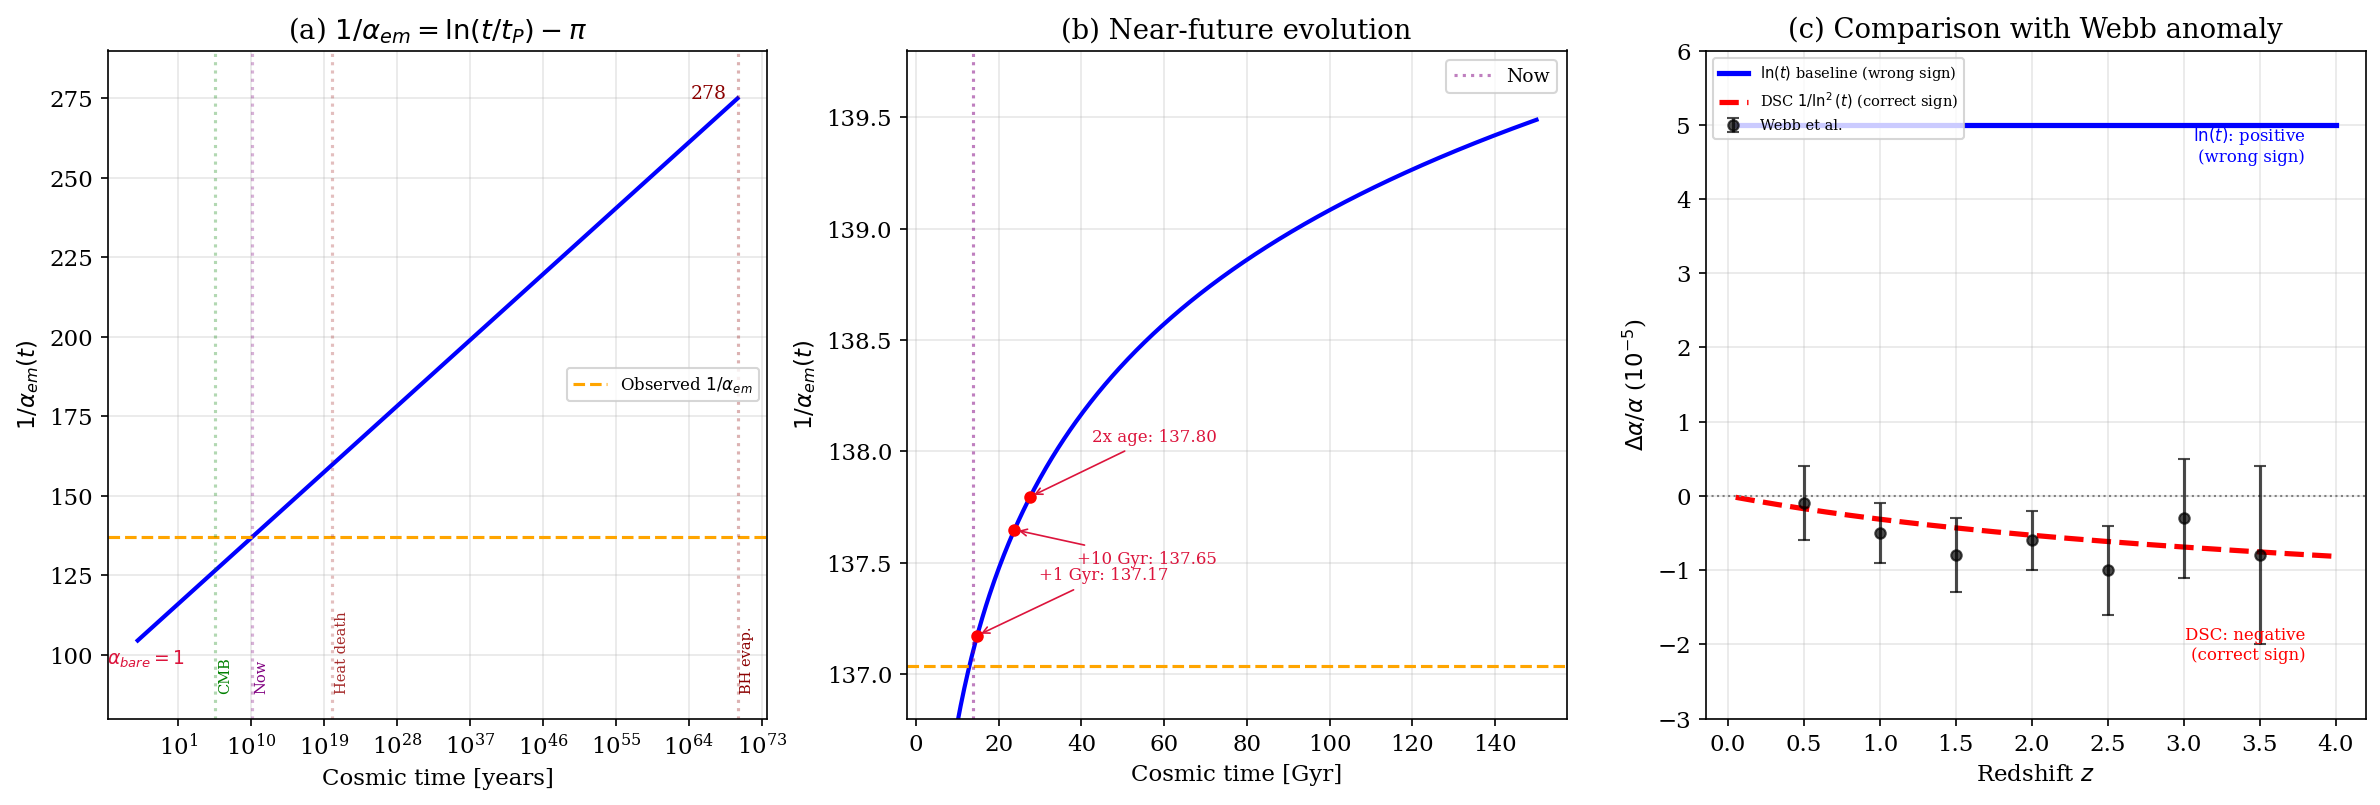

Saved: fig5_alpha_evolution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# (a) Full cosmic timeline
ax = axes[0]
t_yr = np.logspace(np.log10(1e-4), 70, 2000)
ax.semilogx(t_yr, alpha_inv(t_yr * sec_per_yr), 'b-', lw=2)
ax.axhline(137.036, color='orange', ls='--', lw=1.5, label='Observed $1/\\alpha_{em}$')
for t_ep, lab, col in [(3.8e5,'CMB','green'),(13.8e9,'Now','purple'),
                        (1e20,'Heat death','brown'),(1e70,'BH evap.','darkred')]:
    ax.axvline(t_ep, color=col, ls=':', alpha=0.3)
    ax.text(t_ep*2, 88, lab, color=col, fontsize=7, va='bottom', rotation=90)
ax.set_xlabel('Cosmic time [years]'); ax.set_ylabel('$1/\\alpha_{em}(t)$')
ax.set_title('(a) $1/\\alpha_{em} = \\ln(t/t_P) - \\pi$')
ax.set_ylim(80, 290); ax.legend(fontsize=8, loc='center right'); ax.grid(True, alpha=0.3)
ax.text(1e-3, 97, '$\\alpha_{bare}=1$', fontsize=9, color='crimson', ha='center')
ax.text(5e68, 275, '278', fontsize=9, color='darkred', ha='right')

# (b) Zoom: present epoch
ax = axes[1]
t_zoom = np.linspace(5e9, 150e9, 500)
ax.plot(t_zoom/1e9, alpha_inv(t_zoom*sec_per_yr), 'b-', lw=2)
ax.axhline(137.036, color='orange', ls='--', lw=1.5)
ax.axvline(13.8, color='purple', ls=':', alpha=0.5, label='Now')
for dt, lab, xoff, yoff in [(1,'+1 Gyr',15,0.25),(10,'+10 Gyr',15,-0.15),(13.8,'2x age',15,0.25)]:
    val = alpha_inv((13.8+dt)*1e9*sec_per_yr)
    ax.plot(13.8+dt, val, 'ro', markersize=5)
    ax.annotate(f'{lab}: {val:.2f}', xy=(13.8+dt, val), xytext=(13.8+dt+xoff, val+yoff),
                fontsize=8, color='crimson', arrowprops=dict(arrowstyle='->', color='crimson', lw=0.8))
ax.set_xlabel('Cosmic time [Gyr]'); ax.set_ylabel('$1/\\alpha_{em}(t)$')
ax.set_title('(b) Near-future evolution'); ax.set_ylim(136.8, 139.8)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (c) Webb anomaly comparison
ax = axes[2]
z_arr = np.linspace(0.05, 4, 200)
a_inv_now = alpha_inv(t_0)

# ln(t) model: POSITIVE (wrong sign)
da_ln = np.array([(a_inv_now / alpha_inv(z_to_age_sec(z)) - 1) for z in z_arr])
da_ln_display = np.clip(da_ln * 1e5, -5, 5)

# DSC 1/ln^2(t): NEGATIVE (correct sign)
gamma = 5.0
da_dsc = np.array([-gamma*(1/np.log(z_to_age_sec(z)/t_P)**2 - 1/np.log(t_0/t_P)**2) for z in z_arr])

ax.plot(z_arr, da_ln_display, 'b-', lw=2.5, label='$\\ln(t)$ baseline (wrong sign)')
ax.plot(z_arr, da_dsc * 1e5, 'r--', lw=2.5, label='DSC $1/\\ln^2(t)$ (correct sign)')
ax.axhline(0, color='gray', ls=':', lw=1)

# Webb data
z_webb = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
da_webb = [-0.1, -0.5, -0.8, -0.6, -1.0, -0.3, -0.8]
da_err = [0.5, 0.4, 0.5, 0.4, 0.6, 0.8, 1.2]
ax.errorbar(z_webb, da_webb, yerr=da_err, fmt='ko', markersize=5, capsize=3, alpha=0.7, label='Webb et al.')

ax.set_xlabel('Redshift $z$'); ax.set_ylabel('$\\Delta\\alpha/\\alpha$ ($10^{-5}$)')
ax.set_title('(c) Comparison with Webb anomaly')
ax.legend(fontsize=7, loc='upper left'); ax.set_ylim(-3, 6); ax.grid(True, alpha=0.3)
ax.text(3.8, 4.5, '$\\ln(t)$: positive\n(wrong sign)', fontsize=8, color='blue', ha='right')
ax.text(3.8, -2.2, 'DSC: negative\n(correct sign)', fontsize=8, color='red', ha='right')

plt.tight_layout()
plt.savefig('fig5_alpha_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_alpha_evolution.png')